# Exploitation de données électorales avec Python
**Evaluation intermédiaire Python pour la data science (mi-semestre 2026)**

---

## Import des données

In [116]:
import pandas as pd
from great_tables import GT

df = pd.read_csv(
    'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

df.head(10)

/tmp/ipykernel_10187/1626334154.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0
5,01,Ain,7,Ambronay,Nathalie,ARTHAUD,10
6,01,Ain,8,Ambutrix,Nathalie,ARTHAUD,2
7,01,Ain,9,Andert-et-Condon,Nathalie,ARTHAUD,1
8,01,Ain,10,Anglefort,Nathalie,ARTHAUD,5
9,01,Ain,11,Apremont,Nathalie,ARTHAUD,0


---
## 1. Explorations générales

### Question 1

Créer ou mettre à jour les variables suivantes :
- **`code_commune`** : En utilisant la variable déjà existante et le département, remplacer la valeur `code_commune` pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir `92049`.
- **`candidat`** : créer une colonne avec le prénom et le nom mis ensemble, en n'oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls.

In [117]:
# Créer code_commune complet (département + commune sur 3 chiffres)
df["code_commune"] = df["code_departement"].astype(str) + df["code_commune"].astype(str).str.zfill(3)

# Créer la colonne candidat (prenom + nom)
df["candidat"] = df["prenom"].fillna("") + " " + df["nom"].fillna("")
df["candidat"] = df["candidat"].str.strip()  # supprime les espaces inutiles

# Affichage GT pour les 10 premières lignes sans index
GT(df[["code_departement","code_commune","prenom","nom","candidat"]].head(10)) \
    .tab_header(title="Code Commune et Candidat (extrait)") \
    .cols_label(
        code_departement="Département",
        code_commune="Code Commune",
        prenom="Prénom",
        nom="Nom",
        candidat="Candidat"
    )


GT(_tbl_data=  code_departement code_commune    prenom      nom          candidat
0               01        01001  Nathalie  ARTHAUD  Nathalie ARTHAUD
1               01        01002  Nathalie  ARTHAUD  Nathalie ARTHAUD
2               01        01004  Nathalie  ARTHAUD  Nathalie ARTHAUD
3               01        01005  Nathalie  ARTHAUD  Nathalie ARTHAUD
4               01        01006  Nathalie  ARTHAUD  Nathalie ARTHAUD
5               01        01007  Nathalie  ARTHAUD  Nathalie ARTHAUD
6               01        01008  Nathalie  ARTHAUD  Nathalie ARTHAUD
7               01        01009  Nathalie  ARTHAUD  Nathalie ARTHAUD
8               01        01010  Nathalie  ARTHAUD  Nathalie ARTHAUD
9               01        01011  Nathalie  ARTHAUD  Nathalie ARTHAUD, _body=<great_tables._gt_data.Body object at 0x7fac36584d70>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='code_commune', type=<ColInfoTypeEnum.default: 1>, column_label='Code Commune', column_align='right', column_width=None), ColInfo(var='prenom', type=<ColInfoTypeEnum.default: 1>, column_label='Prénom', column_align='left', column_width=None), ColInfo(var='nom', type=<ColInfoTypeEnum.default: 1>, column_label='Nom', column_align='left', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fac51b12bd0>, _spanners=Spanners([]), _heading=Heading(title='Code Commune et Candidat (extrait)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fac41489a90>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fac4148b6b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fac36584cd0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, catego

---
### Question 2

Compléter la phrase suivante grâce à Python :

> En 2022, il y avait XXXXX candidats à l'élection présidentielle

⚠️ Attention aux votes non exprimés et aux abstentions.

Utiliser cette f-string comme réponse :
```python
f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."
```

In [133]:
# Question 2
print(df['candidat'].unique())
candidats = df['candidat'].dropna().nunique()

print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")

['Nathalie ARTHAUD' 'Fabien ROUSSEL' 'Emmanuel MACRON' 'Jean LASSALLE'
 'Marine LE PEN' 'Éric ZEMMOUR' 'Jean-Luc MÉLENCHON' 'Anne HIDALGO'
 'Yannick JADOT' 'Valérie PÉCRESSE' 'Philippe POUTOU'
 'Nicolas DUPONT-AIGNAN' 'abstentions' 'blancs' 'nuls']
En 2022, il y avait 15 candidats à l'élection présidentielle.


---
### Question 3

Calculer les scores nationaux de chaque candidat. Représenter dans un tableau, pour chaque candidat, le **nombre de voix** et le **pourcentage des votes exprimés** (c'est-à-dire en retirant abstentions et votes non exprimés).

Représenter cela dans un dataframe ou, pour avoir tous les points, dans un tableau mis en forme via `great_tables`.

In [ ]:
exclure = ["", "abstentions", "blancs", "nuls"]
votes_exprimes = df[~df["candidat"].isin(exclure)]

scores = votes_exprimes.groupby("candidat")["voix"].sum().reset_index()
total_votes_exprimes = votes_exprimes["voix"].sum()

# Calcul du pourcentage et ajout du symbole %
scores["Score (% votes exprimés)"] = (scores["voix"] / total_votes_exprimes * 100).round(2).map(lambda x: f"{x:.2f} %")

# Renommer les colonnes
scores.rename(columns={
    "candidat": "Candidat",
    "voix": "Nombre votes (total)"
}, inplace=True)

# Trier du plus grand au plus petit
scores = scores.sort_values(by="Nombre votes (total)", ascending=False).reset_index(drop=True)

# Affichage sans index
scores.style.hide(axis="index")
(
    GT(scores)
    .tab_header(title="Résultats du premier tour 2022")
    .cols_label(**{"Candidat": "Candidat", "Nombre votes (total)": "Votes", "Score (% votes exprimés)": "Score (%)"})
    .fmt_number(columns="Nombre votes (total)", decimals=0, sep_mark=" ")
)

GT(_tbl_data=                 Candidat  Nombre votes (total) Score (% votes exprimés)
0         Emmanuel MACRON               9783058                  27.85 %
1           Marine LE PEN               8133828                  23.15 %
2      Jean-Luc MÉLENCHON               7712520                  21.95 %
3            Éric ZEMMOUR               2485226                   7.07 %
4        Valérie PÉCRESSE               1679001                   4.78 %
5           Yannick JADOT               1627853                   4.63 %
6           Jean LASSALLE               1101387                   3.13 %
7          Fabien ROUSSEL                802422                   2.28 %
8   Nicolas DUPONT-AIGNAN                725176                   2.06 %
9            Anne HIDALGO                616478                   1.75 %
10        Philippe POUTOU                268904                   0.77 %
11       Nathalie ARTHAUD                197094                   0.56 %, _body=<great_tables._gt_data.Body object at 0x7fac3424b430>, _boxhead=Boxhead([ColInfo(var='Candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='Nombre votes (total)', type=<ColInfoTypeEnum.default: 1>, column_label='Votes', column_align='right', column_width=None), ColInfo(var='Score (% votes exprimés)', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fac3ab10e90>, _spanners=Spanners([]), _heading=Heading(title='Résultats du premier tour 2022', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fac3426df70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fac3426e9f0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fac3424b5c0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fac3426d8b0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(s

---
## 2. Comparaison des scores départements aux moyennes nationales

### Question 4

Créer un dataframe nommé `score_departements` stockant, pour chaque département, le **nombre de votes** obtenu pour chaque candidat et le **score (en %)**.

In [120]:
# Question 4

score_departements = (
    votes_exprimes
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_departement'})
)

total_dep = (
    votes_exprimes
    .groupby('code_departement')['voix']
    .sum()
    .rename('total_dep')
)

score_departements = score_departements.merge(total_dep, on='code_departement')
score_departements['score_departement'] = score_departements['votes_departement'] / score_departements['total_dep'] * 100
score_departements = score_departements.drop(columns='total_dep')

# Vérification département 11
(
    GT(score_departements[score_departements['code_departement'] == '11'])
    .tab_header(title="Résultats par département - Aude (11)")
    .cols_label(code_departement="Département", candidat="Candidat", votes_departement="Votes", score_departement="Score (%)")
    .fmt_number(columns="votes_departement", decimals=0, sep_mark=" ")
    .fmt_number(columns="score_departement", decimals=2)
)

GT(_tbl_data=    code_departement               candidat  votes_departement  \
120               11           Anne HIDALGO               6166   
121               11        Emmanuel MACRON              43104   
122               11         Fabien ROUSSEL               5622   
123               11          Jean LASSALLE              12382   
124               11     Jean-Luc MÉLENCHON              42039   
125               11          Marine LE PEN              64027   
126               11       Nathalie ARTHAUD               1026   
127               11  Nicolas DUPONT-AIGNAN               4206   
128               11        Philippe POUTOU               1748   
129               11       Valérie PÉCRESSE               7350   
130               11          Yannick JADOT               6322   
131               11           Éric ZEMMOUR              18434   

     score_departement  
120           2.902658  
121          20.291301  
122           2.646569  
123           5.828853  
124          19.789950  
125          30.140849  
126           0.482992  
127           1.979984  
128           0.822875  
129           3.460028  
130           2.976095  
131           8.677845  , _body=<great_tables._gt_data.Body object at 0x7fac474c9040>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Département', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Votes', column_align='right', column_width=None), ColInfo(var='score_departement', type=<ColInfoTypeEnum.default: 1>, column_label='Score (%)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fac51c303b0>, _spanners=Spanners([]), _heading=Heading(title='Résultats par département - Aude (11)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fac3ab11910>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fac3ab118b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fac474c3de0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fac3ab11130>, <great_tables._gt_data.FormatInfo object at 0x7fac3ab117f0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='val

In [121]:
# Vérification : résultat pour l'Aude (département n°11)
score_departements[score_departements['code_departement'] == '11']

,code_departement,candidat,votes_departement,score_departement
120,11,Anne HIDALGO,6166,2.902658
121,11,Emmanuel MACRON,43104,20.291301
122,11,Fabien ROUSSEL,5622,2.646569
123,11,Jean LASSALLE,12382,5.828853
124,11,Jean-Luc MÉLENCHON,42039,19.789950
125,11,Marine LE PEN,64027,30.140849
126,11,Nathalie ARTHAUD,1026,0.482992
127,11,Nicolas DUPONT-AIGNAN,4206,1.979984
128,11,Philippe POUTOU,1748,0.822875
129,11,Valérie PÉCRESSE,7350,3.460028


---
### Question 5

Refaire le lien avec le niveau national pour comparer le score départemental avec le score national. Nommer ce dataframe `score_departements` (nous allons le réutiliser par la suite).

In [122]:
# Question 5 : comparaison score départemental vs score national

# On récupère les scores nationaux dans un dictionnaire pour les fusionner
scores_nationaux_dict = scores.set_index("Candidat")["Score (% votes exprimés)"].str.replace(" %", "").astype(float).to_dict()

# Ajouter le score national à chaque ligne du score_departements
score_departements["score_national"] = score_departements["candidat"].map(scores_nationaux_dict)

# Calcul de l'écart entre score départemental et score national
score_departements["ecart_national"] = score_departements["score_departement"] - score_departements["score_national"]


In [123]:
# Vérification : résultat pour l'Aude (département n°11)
(
    GT(score_departements[score_departements['code_departement'] == '11'])
    .tab_header(title="Résultats - Aude (11)")
    .fmt_number(columns=["votes_departement", "votes_national"], decimals=0, sep_mark=" ")
    .fmt_number(columns=["score_departement", "score_national"], decimals=2)
)

GT(_tbl_data=    code_departement               candidat  votes_departement  \
120               11           Anne HIDALGO               6166   
121               11        Emmanuel MACRON              43104   
122               11         Fabien ROUSSEL               5622   
123               11          Jean LASSALLE              12382   
124               11     Jean-Luc MÉLENCHON              42039   
125               11          Marine LE PEN              64027   
126               11       Nathalie ARTHAUD               1026   
127               11  Nicolas DUPONT-AIGNAN               4206   
128               11        Philippe POUTOU               1748   
129               11       Valérie PÉCRESSE               7350   
130               11          Yannick JADOT               6322   
131               11           Éric ZEMMOUR              18434   

     score_departement  score_national  ecart_national  
120           2.902658            1.75        1.152658  
121          20.291301           27.85       -7.558699  
122           2.646569            2.28        0.366569  
123           5.828853            3.13        2.698853  
124          19.789950           21.95       -2.160050  
125          30.140849           23.15        6.990849  
126           0.482992            0.56       -0.077008  
127           1.979984            2.06       -0.080016  
128           0.822875            0.77        0.052875  
129           3.460028            4.78       -1.319972  
130           2.976095            4.63       -1.653905  
131           8.677845            7.07        1.607845  , _body=<great_tables._gt_data.Body object at 0x7fac476c61c0>, _boxhead=Boxhead([ColInfo(var='code_departement', type=<ColInfoTypeEnum.default: 1>, column_label='code_departement', column_align='right', column_width=None), ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='candidat', column_align='left', column_width=None), ColInfo(var='votes_departement', type=<ColInfoTypeEnum.default: 1>, column_label='votes_departement', column_align='right', column_width=None), ColInfo(var='score_departement', type=<ColInfoTypeEnum.default: 1>, column_label='score_departement', column_align='right', column_width=None), ColInfo(var='score_national', type=<ColInfoTypeEnum.default: 1>, column_label='score_national', column_align='right', column_width=None), ColInfo(var='ecart_national', type=<ColInfoTypeEnum.default: 1>, column_label='ecart_national', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fac3ab12cf0>, _spanners=Spanners([]), _heading=Heading(title='Résultats - Aude (11)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fac3ab13d70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fac3ab13dd0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fac476c5a40>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fac3ab13e90>, <great_tables._gt_data.FormatInfo object at 0x7fac3ab13fb0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu',

---
### Question 6

Créer une variable **`surrepresentation`** qui compare, en relatif, les scores nationaux et départementaux.

Par exemple, si un candidat a un score de 30% dans un département mais de 15% ailleurs, la valeur de `surrepresentation` sera égale à **100 (%)**.

In [124]:
# Question 6

score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
)

---
### Question 7

Créer une **fonction** pour représenter une figure des principales surreprésentations (en valeur absolue) par département, pour un candidat donné.

In [125]:
# Question 7


---
## 3. Un peu de cartographie

Récupération du fond de carte des départements :

In [126]:
from cartiflette import carti_download

departement_borders = carti_download(
    values = ["France"],
    crs = 4326,
    borders = "DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

---
### Question 8

Faire une **fonction** permettant de restreindre `score_departements` en fonction d'un candidat. Commencer par tester sur **Marine Le Pen** (créer un nouvel objet, ne pas écraser `score_departements`).

Faire une jointure au fond de carte des départements et effectuer une **carte de la surreprésentation**.

In [127]:
departement_borders.columns

Index(['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE',
       'geometry'],
      dtype='object')

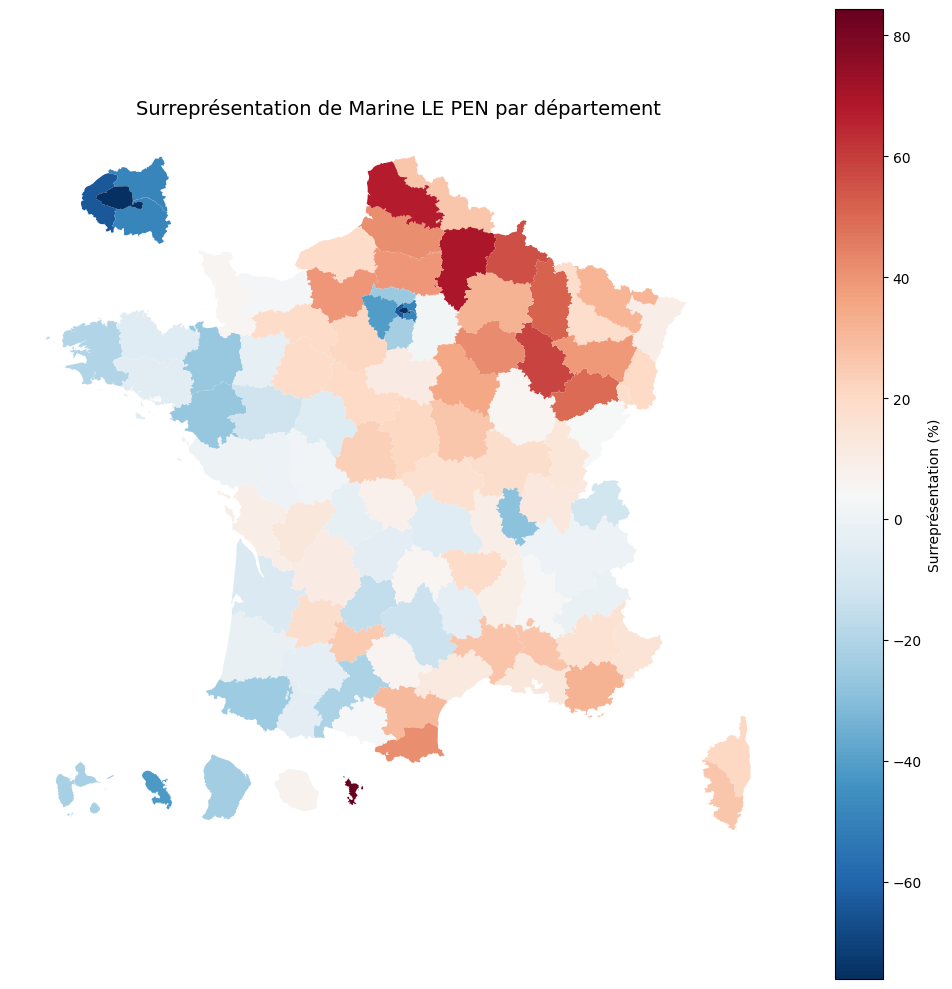

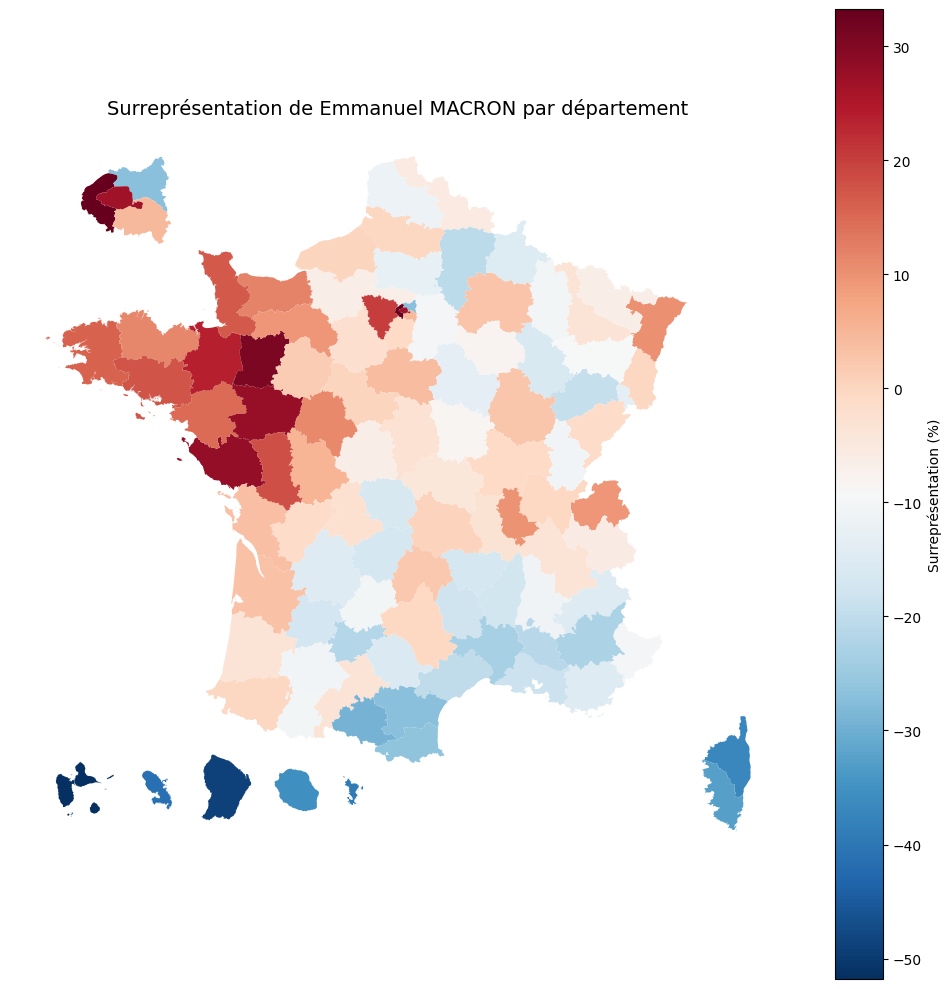

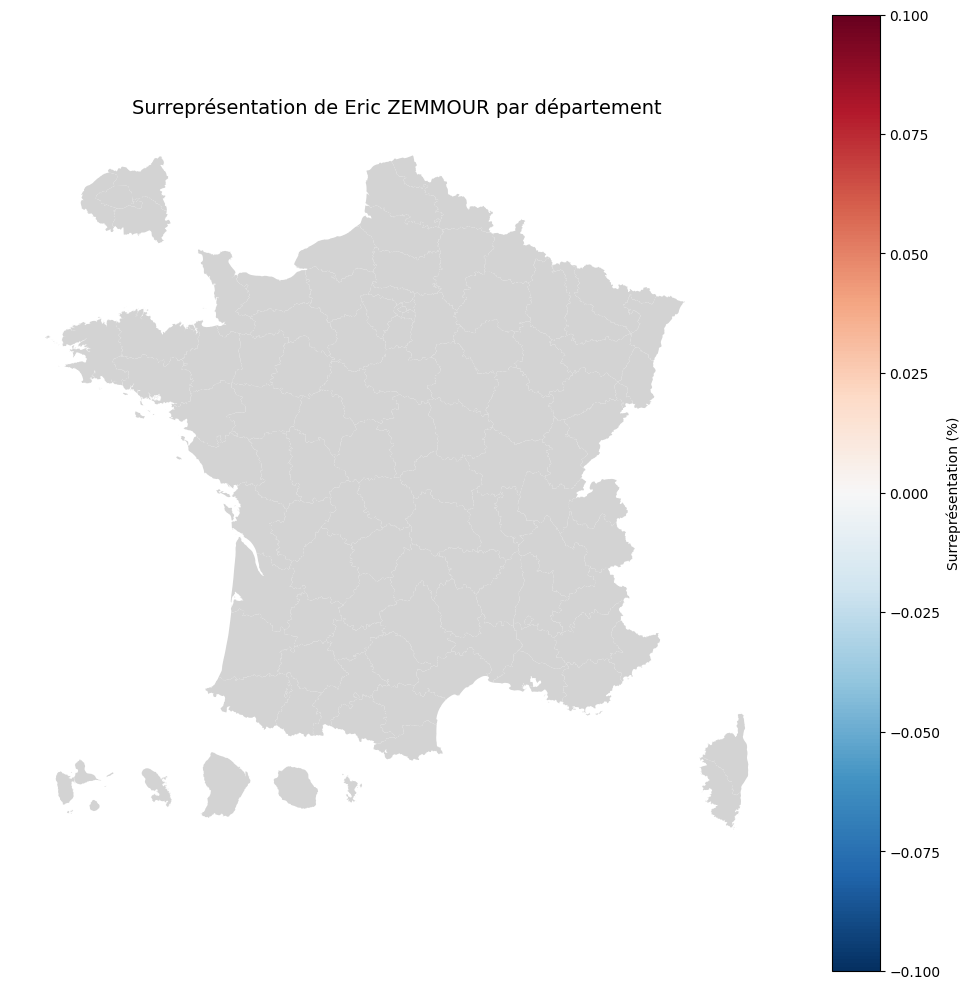

In [129]:
# Question 8
from cartiflette import carti_download
import geopandas as gpd
import matplotlib.pyplot as plt

departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

def carte_candidat(candidat):
    df_candidat = score_departements[score_departements['candidat'] == candidat].copy()
    
    gdf = departement_borders.merge(
        df_candidat,
        left_on='INSEE_DEP',
        right_on='code_departement',
        how='left'
    )
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf.plot(
        column='surrepresentation',
        ax=ax,
        legend=True,
        cmap='RdBu_r',
        legend_kwds={'label': 'Surreprésentation (%)'},
        missing_kwds={'color': 'lightgrey'}
    )
    ax.set_title(f"Surreprésentation de {candidat} par département", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Test sur Marine Le Pen et Emmanuel Macron
carte_candidat('Marine LE PEN')
carte_candidat('Emmanuel MACRON')
carte_candidat('Eric ZEMMOUR')